# Imports

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps
import glob

# map def

In [2]:
def reg_map(
    ds_to_plt,
    dots,
    bounds=[20, -180, 30, -30],
    name="figure",
    color=cmaps.posneg_1,
    lcolor=["magenta", "cyan"],
    lev=np.arange(-1.5, 1.5, 0.15),
):
    fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    cdot, cdot_lon = cutil.add_cyclic_point(dots, dots.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2] + 1, 15)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0, 0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())

    ds_plot = ax.contourf(
        clon,
        ds_to_plt.lat,
        cdat,
        levels=lev,
        # levels=40,
        transform=ccrs.PlateCarree(),
        cmap=color,
        extend="both",
    )

    dot_plot = ax.contourf(
        cdot_lon,
        dots.lat,
        cdot,
        transform=ccrs.PlateCarree(),
        linestyles="-",
        hatches=["..", ""],
        levels=[0, 0.05],
        colors="None",  # lcolor,
        alpha=0.1,
    )

    fig.canvas.mpl_connect("resize_event", resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(ds_plot, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

# Import Data

In [3]:
files = glob.glob('/glade/work/acruz/E3SMv2LE/Regressions/*')
files

['/glade/work/acruz/E3SMv2LE/Regressions/PRECCA',
 '/glade/work/acruz/E3SMv2LE/Regressions/SSTA']

In [4]:
PRECCAds = xr.open_zarr(files[0])
PRECCAds

<xarray.Dataset> Size: 37MB
Dimensions:                (member: 21, lat: 192, lon: 288)
Coordinates:
  * member                 (member) int64 168B 0 1 2 3 4 5 ... 15 16 17 18 19 20
  * lat                    (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                    (lon) float64 2kB -180.0 -178.8 ... 177.5 178.8
Data variables:
    JJA_PRECCA_CANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    JJA_PRECCA_CANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    JJA_PRECCA_EANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    JJA_PRECCA_EANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    SON_PRECCA_CANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    SON_PRECCA_CANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    SON_PRECCA_EANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    SON_PRECCA_EANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
Attributes:
    Description:  Linear regression results from E3SM convective precipitatio...

# Masking by Pval

In [5]:
pvt = 0.05

JJA_PRECCA_EANI = PRECCAds['JJA_PRECCA_EANI_slope'].where(
        PRECCAds['JJA_PRECCA_EANI_pval'] <= pvt
)
JJA_PRECCA_CANI = PRECCAds['JJA_PRECCA_CANI_slope'].where(
    PRECCAds['JJA_PRECCA_CANI_pval'] <= pvt
)
SON_PRECCA_EANI = PRECCAds['SON_PRECCA_EANI_slope'].where(
    PRECCAds['SON_PRECCA_EANI_pval'] <= pvt
)
SON_PRECCA_CANI = PRECCAds['SON_PRECCA_CANI_slope'].where(
    PRECCAds['SON_PRECCA_CANI_pval'] <= pvt
)

In [6]:
SSTAds = xr.open_zarr(files[1])
SSTAds

<xarray.Dataset> Size: 37MB
Dimensions:              (member: 21, lat: 192, lon: 288)
Coordinates:
  * member               (member) int64 168B 0 1 2 3 4 5 6 ... 15 16 17 18 19 20
  * lat                  (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                  (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
Data variables:
    JJA_SSTA_CANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    JJA_SSTA_CANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    JJA_SSTA_EANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    JJA_SSTA_EANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    SON_SSTA_CANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    SON_SSTA_CANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
    SON_SSTA_EANI_pval   (member, lat, lon) float32 5MB dask.array<chunksize=(11, 96, 144), meta=np.ndarray>
    SON_SSTA_EANI_slope  (member, lat, lon) float32 5MB dask.array<chunksize=(21, 192, 288), meta=np.ndarray>
Attributes:
    Description:  Linear regression results from E3SM SST anomaalies between ...

In [7]:
JJA_SSTA_EANI = SSTAds['JJA_SSTA_EANI_slope'].where(
    SSTAds['JJA_SSTA_EANI_pval'] <= pvt
)
JJA_SSTA_CANI = SSTAds['JJA_SSTA_CANI_slope'].where(
    SSTAds['JJA_SSTA_CANI_pval'] <= pvt
)
SON_SSTA_EANI = SSTAds['SON_SSTA_EANI_slope'].where(
    SSTAds['SON_SSTA_EANI_pval'] <= pvt
)
SON_SSTA_CANI = SSTAds['SON_SSTA_CANI_slope'].where(
    SSTAds['SON_SSTA_CANI_pval'] <= pvt
)

# Ensemble means

In [8]:
JJA_PRECCA_EANIensm = JJA_PRECCA_EANI.mean(dim='member')
JJA_PRECCA_CANIensm = JJA_PRECCA_CANI.mean(dim='member')
SON_PRECCA_EANIensm = SON_PRECCA_EANI.mean(dim='member')
SON_PRECCA_CANIensm = SON_PRECCA_CANI.mean(dim='member')

JJA_SSTA_EANIensm = JJA_SSTA_EANI.mean(dim='member')
JJA_SSTA_CANIensm = JJA_SSTA_CANI.mean(dim='member')
SON_SSTA_EANIensm = SON_SSTA_EANI.mean(dim='member')
SON_SSTA_CANIensm = SON_SSTA_CANI.mean(dim='member')

In [9]:
JJA_PRECCA_EANIdots = PRECCAds['JJA_PRECCA_EANI_pval'].mean(dim='member')
JJA_PRECCA_CANIdots = PRECCAds['JJA_PRECCA_CANI_pval'].mean(dim='member')
SON_PRECCA_EANIdots = PRECCAds['SON_PRECCA_EANI_pval'].mean(dim='member')
SON_PRECCA_CANIdots = PRECCAds['SON_PRECCA_CANI_pval'].mean(dim='member')

JJA_SSTA_EANIdots = SSTAds['JJA_SSTA_EANI_pval'].mean(dim='member')
JJA_SSTA_CANIdots = SSTAds['JJA_SSTA_CANI_pval'].mean(dim='member')
SON_SSTA_EANIdots = SSTAds['SON_SSTA_EANI_pval'].mean(dim='member')
SON_SSTA_CANIdots = SSTAds['SON_SSTA_CANI_pval'].mean(dim='member')

# Plots

## SST

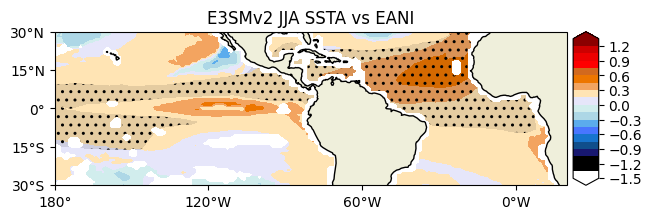

In [10]:
reg_map(JJA_SSTA_EANIensm, JJA_SSTA_EANIdots,
        name='E3SMv2 JJA SSTA vs EANI')

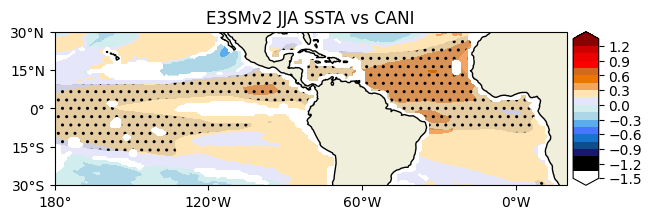

In [11]:
reg_map(JJA_SSTA_CANIensm, JJA_SSTA_CANIdots,
        name='E3SMv2 JJA SSTA vs CANI')

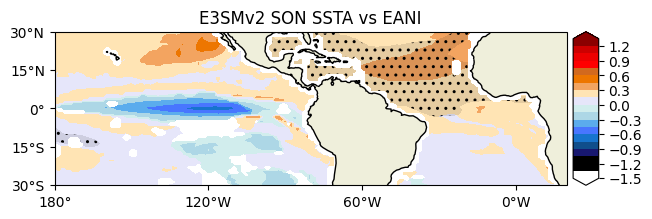

In [12]:
reg_map(SON_SSTA_EANIensm, SON_SSTA_EANIdots,
        name='E3SMv2 SON SSTA vs EANI')

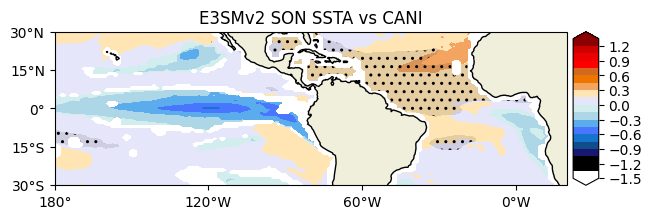

In [13]:
reg_map(SON_SSTA_CANIensm, SON_SSTA_CANIdots,
        name='E3SMv2 SON SSTA vs CANI')

## Precip

In [14]:
# conversion from m/s to mm/day
JJA_PRECCA_EANIensm = JJA_PRECCA_EANIensm * ( 1000 * (24*60*60))

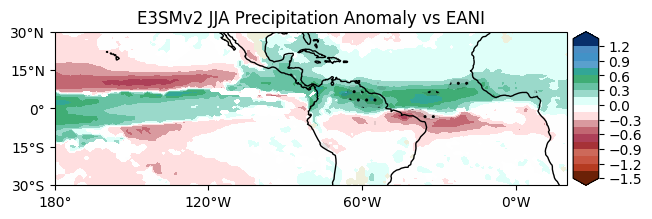

In [15]:
reg_map(JJA_PRECCA_EANIensm, JJA_PRECCA_EANIdots,
        name='E3SMv2 JJA Precipitation Anomaly vs EANI',
        color=cmaps.precip4_diff_19lev)

In [16]:
# conversion from m/s to mm/day
JJA_PRECCA_CANIensm = JJA_PRECCA_CANIensm * ( 1000 * (24*60*60))

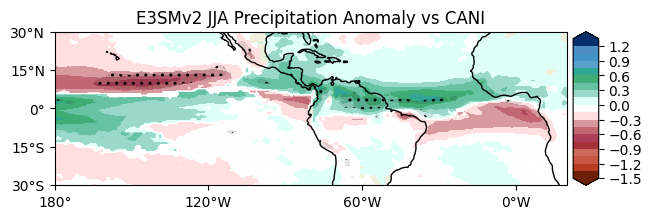

In [17]:
reg_map(JJA_PRECCA_CANIensm, JJA_PRECCA_CANIdots,
        name='E3SMv2 JJA Precipitation Anomaly vs CANI',
        color=cmaps.precip4_diff_19lev)

In [18]:
# conversion from m/s to mm/day
SON_PRECCA_EANIensm =  SON_PRECCA_EANIensm * ( 1000 * (24*60*60))

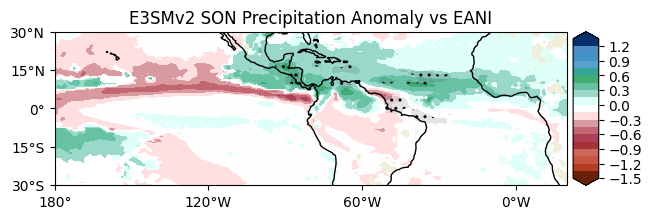

In [19]:
reg_map(SON_PRECCA_EANIensm, SON_PRECCA_EANIdots,
        name='E3SMv2 SON Precipitation Anomaly vs EANI',
        color=cmaps.precip4_diff_19lev)

In [20]:
# conversion from m/s to mm/day
SON_PRECCA_CANIensm = SON_PRECCA_CANIensm * ( 1000 * (24*60*60))

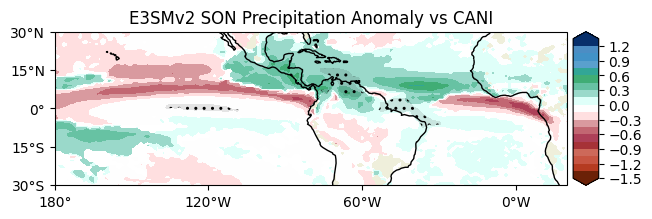

In [22]:
reg_map(SON_PRECCA_CANIensm, SON_PRECCA_CANIdots,
        name='E3SMv2 SON Precipitation Anomaly vs CANI',
        color=cmaps.precip4_diff_19lev)